# The TW Project

## Stage 1: Finetune a YOLO26s on LLVIP dataset

### Data preparation

In [ ]:
"""Download the dataset"""

import os


def download_dataset():
    import gdown

    url = "https://drive.google.com/uc?id=1VTlT3Y7e1h-Zsne4zahjx5q0TK2ClMVv"
    gdown.download(
        url=url,
        output="datasets.zip",
    )

if (not os.path.exists("datasets.zip")):
    print("Dataset not downloaded, now downloading")
    download_dataset()
else:
    import hashlib

    with open("datasets.zip", "rb") as f:
        file_hash = hashlib.md5()
        while chunk := f.read(8192):
            file_hash.update(chunk)
    if file_hash.hexdigest() != "e64affb4b0b50e1772ff6f67da873bf6":
        print("Download dataset again due to hash mismatch")
        download_dataset()

if (not os.path.exists("datasets")):
    import zipfile
    
    with zipfile.ZipFile("datasets.zip", "r") as zip_ref:
        zip_ref.extractall("datasets")

In [12]:
"""Convert VOC format to YOLO format."""

from pathlib import Path
import xml.etree.ElementTree as ET
from tqdm.notebook import tqdm


base_path = Path("datasets/LLVIP").resolve()
SPLITS = {"train": 12025, "val": 3463}

def convert_box(size, box):
    dw, dh = 1.0 / size[0], 1.0 / size[1]
    x, y, w, h = (box[0] + box[1]) / 2.0 - 1, (box[2] + box[3]) / 2.0 - 1, box[1] - box[0], box[3] - box[2]
    return x * dw, y * dh, w * dw, h * dh

def convert_label(xml_path, lb_path):
    """Converts XML annotations from VOC format to YOLO format."""
    if not xml_path.exists():
        return
    with open(xml_path, "r", encoding="utf-8") as in_file, open(lb_path, "w", encoding="utf-8") as out_file:
        root = ET.parse(in_file).getroot()
        size = root.find("size")
        w, h = int(size.find("width").text), int(size.find("height").text)
        for obj in root.iter("object"):
            if obj.find("name").text == "person":
                xmlbox = obj.find("bndbox")
                bb = convert_box((w, h), [float(xmlbox.find(x).text) for x in ("xmin", "xmax", "ymin", "ymax")])
                out_file.write(f"0 {' '.join(str(a) for a in bb)}\n")

def process_split(split, source_subdir, expected_count):
    for folder in ["images", "labels"]:
        (base_path / folder / split).mkdir(parents=True, exist_ok=True)

    images = sorted((base_path / "infrared" / source_subdir).glob("*.jpg"))
    assert len(images) == expected_count

    for img_path in tqdm(images, desc=f"Processing {split} split"):
        (base_path / "images" / split / img_path.name).parent.mkdir(parents=True, exist_ok=True)
        img_path.rename(base_path / "images" / split / img_path.name)
        convert_label(
            base_path / "Annotations" / img_path.with_suffix(".xml").name,
            base_path / "labels" / split / img_path.with_suffix(".txt").name,
        )

process_split("train", "train", SPLITS["train"])
process_split("val", "test", SPLITS["val"])  # test set used as val

Processing train split:   0%|          | 0/12025 [00:00<?, ?it/s]

Processing val split:   0%|          | 0/3463 [00:00<?, ?it/s]

In [13]:
"""Create dataset YAML file"""

yaml_path = base_path / "llvip.yaml"
yaml_content = f"""path: {base_path}
train: {base_path / 'images' / 'train'}
val: {base_path / 'images' / 'val'}
nc: 1
names: ['person']
"""

yaml_path.write_text(yaml_content, encoding="utf-8")

168

### Tuning and training

In [1]:
from pathlib import Path
from ultralytics import YOLO
from ultralytics.models.yolo.detect import DetectionTrainer


class CustomSaveTrainer(DetectionTrainer):
    """Trainer that saves the best model based on recall instead of default fitness."""

    def validate(self):
        """Override fitness to use recall for best model selection."""
        metrics, fitness = super().validate()
        if metrics:
            recall  = metrics.get("metrics/recall(B)", 0.0)
            map50   = metrics.get("metrics/mAP50(B)", 0.0)
            map5095 = metrics.get("metrics/mAP50-95(B)", 0.0)

            fitness = (0.60 * recall) + (0.30 * map5095) + (0.10 * map50)

            if self.best_fitness is None or fitness > self.best_fitness:
                self.best_fitness = fitness
        return metrics, fitness


yaml_path = Path("datasets/LLVIP/llvip.yaml").resolve()

In [ ]:
"""Train stage 1"""

from ultralytics import YOLO


model = YOLO("yolo26s.pt")
model.train(
    data=yaml_path,
    epochs=20,
    imgsz=960,
    batch=16,
    optimizer="MuSGD",
    lr0=5e-4,
    lrf=0.1,
    momentum=0.948,
    name="llvip_yolo26s_stage_1",
    cache='disk',
    freeze=10,
    trainer=CustomSaveTrainer,
    exist_ok=True,
    # Augmentation
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.2,
    degrees=0.0,
    translate=0.1,
    scale=0.4,
    shear=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=0.2,
    mixup=0.0,
    erasing=0.2,
)

Ultralytics 8.4.46 🚀 Python-3.14.4 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060, 5736MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/w/tw_project/datasets/LLVIP/llvip.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.948, mosaic=0.2, multi_scale=0.0, name=llvip_yolo26s_stage_1, nbs=64, nms=False, opset=None, optimize=False, optimizer

In [ ]:
"""Train stage 2"""

from ultralytics import YOLO


model = YOLO("runs/detect/llvip_yolo26s_stage_1/weights/best.pt")
model.train(
    data=yaml_path,
    epochs=150,
    imgsz=960,
    batch=16,
    optimizer="MuSGD",
    lr0=1e-4,
    lrf=0.02,
    momentum=0.937,
    warmup_epochs=5,
    name="llvip_yolo26s_stage_2_rc",
    patience=50,
    cache='disk',
    trainer=CustomSaveTrainer,
    exist_ok=True,
    close_mosaic=70,
    # Augmentation
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.2,
    degrees=5.0,
    translate=0.2,
    scale=0.4,
    flipud=0.0,
    fliplr=0.5,
    mosaic=0.2,
    mixup=0.0,
    erasing=0.2,
)

New https://pypi.org/project/ultralytics/8.4.48 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.46 🚀 Python-3.14.4 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060, 5736MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=70, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/w/tw_project/datasets/LLVIP/llvip.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.02, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/llvip_yolo26s_stage_1/we

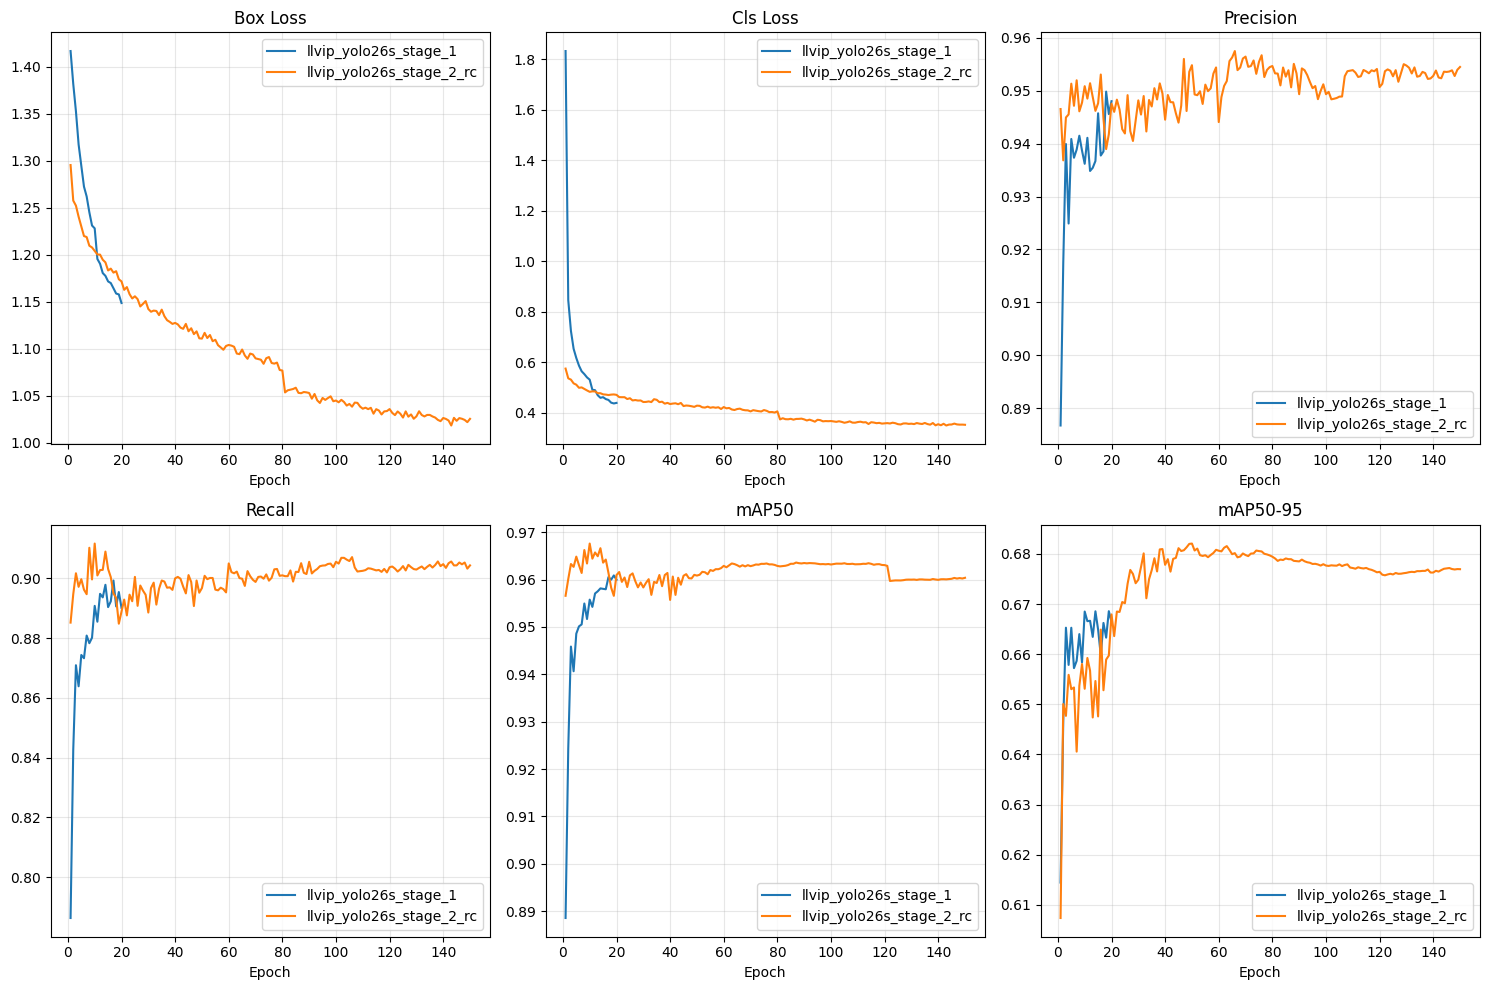

In [1]:
"""View training metrics"""

%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def plot_training_metrics(*run_dirs, figsize=(15, 10)):
    metrics = [
        ("train/box_loss",  "Box Loss"),
        ("train/cls_loss",  "Cls Loss"),
        ("metrics/precision(B)", "Precision"),
        ("metrics/recall(B)",    "Recall"),
        ("metrics/mAP50(B)",     "mAP50"),
        ("metrics/mAP50-95(B)",  "mAP50-95"),
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()
    
    for run_dir in run_dirs:
        csv_path = Path(run_dir) / "results.csv"
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        label = Path(run_dir).name
        
        for ax, (col, title) in zip(axes, metrics):
            if col in df.columns:
                ax.plot(df["epoch"], df[col], label=label)
                ax.set_title(title)
                ax.set_xlabel("Epoch")
                ax.legend()
                ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


plot_training_metrics(
    "runs/detect/llvip_yolo26s_stage_1",
    "runs/detect/llvip_yolo26s_stage_2_rc",
)